In [1]:
library(readr)
library(ggcorrplot)
df <- read_csv("train_time_series.csv")
head(df)
library(dplyr)
numeric_df <- df %>% select(where(is.numeric))

Загрузка требуемого пакета: ggplot2

Rows: 3000888 Columns: 6
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): family
dbl  (4): id, store_nbr, sales, onpromotion
date (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


id,date,store_nbr,family,sales,onpromotion
<dbl>,<date>,<dbl>,<chr>,<dbl>,<dbl>
0,2013-01-01,1,AUTOMOTIVE,0,0
1,2013-01-01,1,BABY CARE,0,0
2,2013-01-01,1,BEAUTY,0,0
3,2013-01-01,1,BEVERAGES,0,0
4,2013-01-01,1,BOOKS,0,0
5,2013-01-01,1,BREAD/BAKERY,0,0



Присоединяю пакет: 'dplyr'


Следующие объекты скрыты от 'package:stats':

    filter, lag


Следующие объекты скрыты от 'package:base':

    intersect, setdiff, setequal, union




In [2]:
df$date <- as.Date(df$date, format = "%Y-%m-%d") 
str(df)
df_ts <- ts(df$sales, start=c(2020,1), frequency=365)
numeric_df <- numeric_df %>% 
  mutate(across(everything(), ~ ifelse(is.na(.), mean(., na.rm = TRUE), .)))


spc_tbl_ [3,000,888 × 6] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ id         : num [1:3000888] 0 1 2 3 4 5 6 7 8 9 ...
 $ date       : Date[1:3000888], format: "2013-01-01" "2013-01-01" ...
 $ store_nbr  : num [1:3000888] 1 1 1 1 1 1 1 1 1 1 ...
 $ family     : chr [1:3000888] "AUTOMOTIVE" "BABY CARE" "BEAUTY" "BEVERAGES" ...
 $ sales      : num [1:3000888] 0 0 0 0 0 0 0 0 0 0 ...
 $ onpromotion: num [1:3000888] 0 0 0 0 0 0 0 0 0 0 ...
 - attr(*, "spec")=
  .. cols(
  ..   id = col_double(),
  ..   date = col_date(format = ""),
  ..   store_nbr = col_double(),
  ..   family = col_character(),
  ..   sales = col_double(),
  ..   onpromotion = col_double()
  .. )
 - attr(*, "problems")=<externalptr> 


Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 



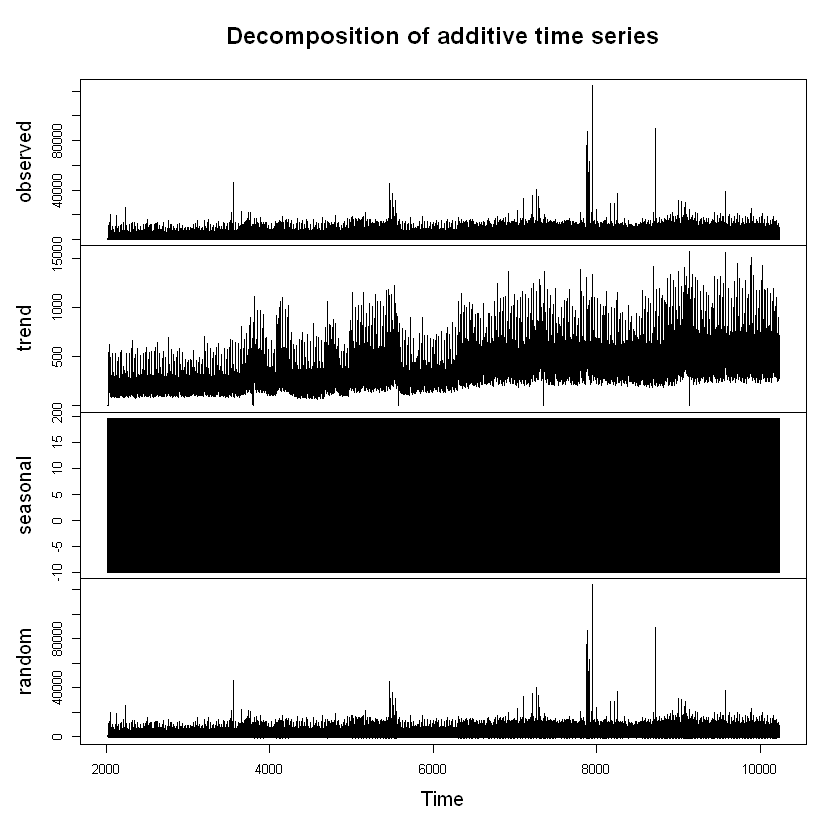

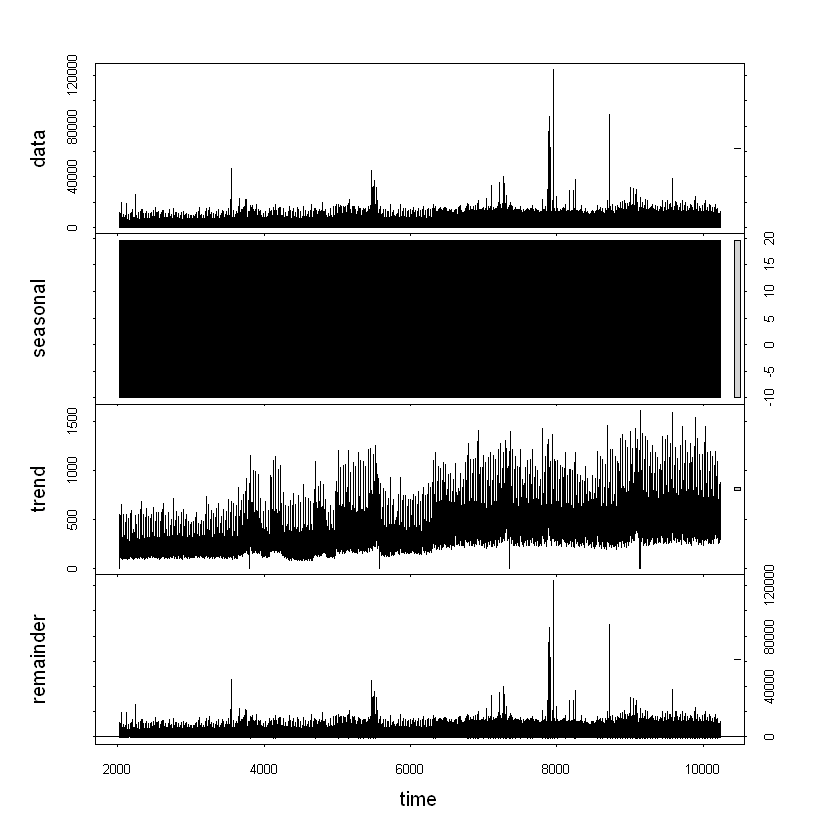

In [3]:
# df_ts (для ежедневных данных, к примеру)
df_ts <- ts(df$sales, start=c(2020,1), frequency=365)
decomp <- decompose(df_ts, type="additive") 

plot(decomp)

library(forecast)
# Автоматическая декомпозиция STL
fit <- stl(df_ts, s.window="periodic")
plot(fit)

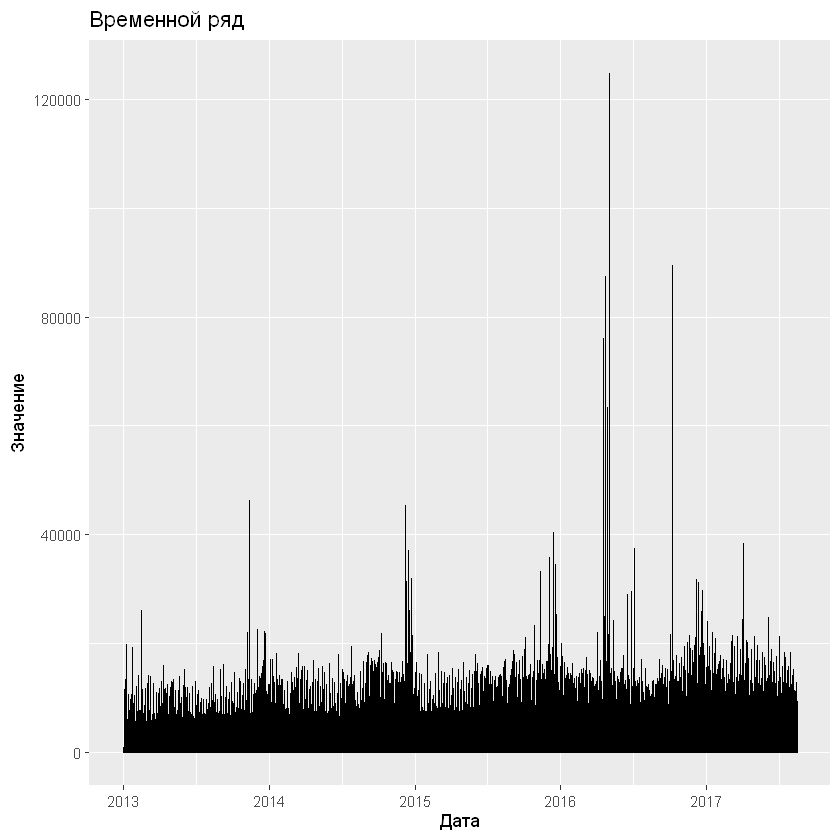

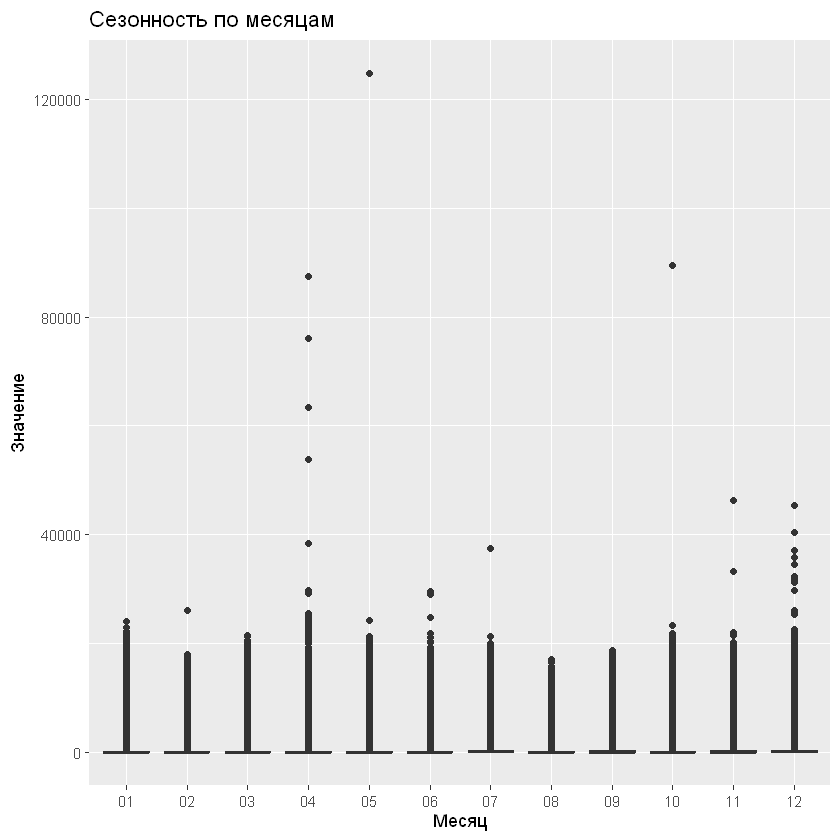

In [4]:
ggplot(df, aes(x=date, y=sales)) +
geom_line() +
ggtitle("Временной ряд") +
xlab("Дата") + ylab("Значение")
df$Month <- format(df$date, "%m")
ggplot(df, aes(x=Month, y=sales)) +
geom_boxplot() +
ggtitle("Сезонность по месяцам") +
xlab("Месяц") + ylab("Значение")